In [1]:
from datetime import datetime

import pandas as pd
import pyarrow
import pyarrow.compute as pc
import pyarrow.dataset as ds

import brasa

man = brasa.engine.CacheManager()

<Axes: xlabel='Data', ylabel='Preço de fechamento'>

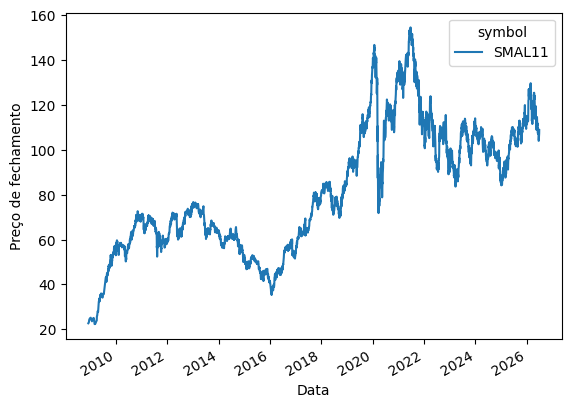

In [2]:
df = brasa.sql("""
select refdate, symbol, close from "staging.b3-cotahist" where symbol in ('SMAL11')
                            """)
dl = df.df().pivot_table(index="refdate", columns="symbol", values="close")
dl.plot(kind="line", ylabel="Preço de fechamento", xlabel="Data")

In [6]:
brasa.sql("""
select * from "staging.b3-listed-funds" where fund_type = 'ETF' and refdate = '2026-06-27'
                            """).df()

,refdate,asset_name,symbol,fund_name,fund_type,fund_id,trading_name
0,2026-06-27,BMMT,BMMT11,B- INDEX MORNINGSTAR BRASIL MOMENTO FUNDO DE Í...,ETF,9253,B INDEX MOME
1,2026-06-27,AGRI,AGRI11,BB ETF IAGRO-FFS B3 FUNDO DE ÍNDICE RESPONSABI...,ETF,8038,BB ETF IAGRO
2,2026-06-27,BBOV,BBOV11,BB ETF IBOVESPA FUNDO DE ÍNDICE RESPONSABILIDA...,ETF,3665,BB ETF IBOV
3,2026-06-27,BRAZ,BRAZ11,BB ETF ÍNDICE BOVESPA B3 BR+ FUNDO DE ÍNDICE R...,ETF,15863,BB ETF BRAZ
4,2026-06-27,DVER,DVER11,BB ETF ÍNDICE DIVERSIDADE B3 INVESTIMENTO SUST...,ETF,10719,BB ETF DVER
...,...,...,...,...,...,...,...
115,2026-06-27,SLVR,SLVR11,TREND ETF LBMA PRATA CLASSE DE ÍNDICE - RESPON...,ETF,25254,TREND PRATA
116,2026-06-27,NASD,NASD11,TREND ETF NASDAQ 100 CLASSE DE ÍNDICE INVESTIM...,ETF,6199,TREND NASDAQ
117,2026-06-27,DOLX,DOLX11,TREND ETF S&P / B3 DOLAR CLASSE DE ÍNDICE - RE...,ETF,23845,TREND DOLAR
118,2026-06-27,SPXU,SPXU11,TREND ETF S&P 500 FUTURES USD-BRLCLASSE DE ÍN...,ETF,7408,TRD SPX USD


In [7]:
brasa.sql("""
select distinct fund_type from "staging.b3-listed-funds"
                            """).df()

,fund_type
0,ETF
1,ETF-FII
2,ETF-CRIPTO
3,ETF-RF


In [6]:
import bizdays

cal = bizdays.Calendar.load("B3")
idx = cal.seq(dl.index.min(), dl.index.max())
dl.reindex(idx).isnull().sum()

symbol
SMAL11    118
dtype: int64

In [3]:
ch = (
    brasa.get_dataset("b3-cotahist")
    .filter(pc.field("refdate") >= datetime(2018, 1, 1))
    .filter(pc.field("symbol") == "MGLU3")
    .scanner(columns=["refdate", "close", "distribution_id"])
    .to_table()
    .to_pandas()
    .set_index("refdate")
)

In [4]:
rets = brasa.get_returns("MGLU3")

In [5]:
brasa.get_dataset("b3-equities-returns").filter(
    pc.field("refdate") >= datetime(2018, 1, 1)
).filter(pc.field("symbol") == "MGLU3").scanner(
    columns=["refdate", "pct_return"]
).to_table().to_pandas().set_index("refdate").to_clipboard()

In [ ]:
# pd.concat([ch, rets], axis=1).to_excel("MGLU3.xlsx")


In [22]:
brasa.get_dataset("b3-companies-cash-dividends").filter(
    pc.field("symbol") == "MGLU3"
).filter(
    pc.field("last_date_prior_ex") >= datetime(2018, 1, 1)
).to_table().to_pandas().to_clipboard()

In [20]:
import re

# x = [s.replace(" ", "").replace(".", "").replace("/", "") for s in brasa.get_symbols("company-trading-name")]
x = [re.sub(r"[^A-Z0-9]", "", s) for s in brasa.get_symbols("company-trading-name")]
for i in x:
    print(i)

3RPETROLEUM
3TENTOS
524PARTICIP
ABCBRASIL
ACOALTONA
AERIS
AESBRASIL
AESOPERACOES
AFLUENTET
AGIBANKBC
AGRIBRASIL
AGROGALAXY
ALFACONSORC
ALFAFINANC
ALFAHOLDING
ALFAINVEST
ALIPERTI
ALLNORTE
ALLIAR
ALLIED
ALLOS
ALPARGATAS
ALPERSA
ALPHAVILLE
ALUPAR
AMAZONIA
AMBEVSA
AMBIPAR
AMERICANAS
AMPLAENERG
ANIMA
AREZZOCO
ARMAC
ASSAI
ATMASA
ATOMPAR
AUREN
AZEVEDO
AZUL
B3
BAHEMA
BANCOBMG
BANCOPAN
BANESE
BANESTES
BANPARA
BANRISUL
BARDELLA
BAUMER
BBMLOGISTICA
BBSEGURIDADE
BEMOBITECH
BETAPART
BICMONARK
BIOMM
BLAU
BOASAFRA
BOMBRIL
BRPARTNERS
BRADESCO
BRADESPAR
BRASIL
BRASILAGRO
BRASKEM
BRBBANCO
BRFSA
BRISANET
BRQ
BTGPBANCO
CABINDAPART
CAIXASEGURI
CAMBUCI
CAMIL
CARREFOURBR
CASAN
CASASBAHIA
CBA
CCRSA
CEAMODAS
CEB
CEDRO
CEEED
CEEEG
CEG
CELESC
CELGPAR
CEMEPE
CEMIG
CEPISA
CIELO
CIMS
CLAROSA
CLEARSALE
COELBA
COELCE
COGNAON
COMERCPAR
COMGAS
COMPASS
CONCRIOTER
CONSTALIND
COPASA
COPEL
CORRIBEIRO
CORSAN
COSAN
COSERN
COTEMINAS
CPFLENERGIA
CRISTAL
CRUZEIROEDU
CSNMINERACAO
CSUDIGITAL
CURYSA
CVCBRASIL
CYRELAREALT
D1000VFAR

In [21]:
brasa.download_marketdata("b3-cash-dividends", tradingName=x)

In [28]:
brasa.get_dataset("b3-companies-cash-dividends").filter(
    pc.field("symbol") == "ABEV3"
).to_table().to_pandas()
# .filter(pc.field("last_date_prior_ex") >= datetime(2018, 1, 1))\

,approved_on,last_date_prior_ex,value_cash,ratio,corporate_action_label,refdate,payment_date,symbol
0,2014-01-06,2014-01-14,0.1000,1,DIVIDENDO,2024-01-18,NaT,ABEV3
1,2014-01-06,2014-01-14,0.1540,1,JRS CAP PROPRIO,2024-01-18,NaT,ABEV3
2,2014-03-25,2014-04-02,0.0600,1,DIVIDENDO,2024-01-18,NaT,ABEV3
3,2014-03-25,2014-04-02,0.0700,1,DIVIDENDO,2024-01-18,NaT,ABEV3
4,2014-07-14,2014-07-28,0.0600,1,DIVIDENDO,2024-01-18,NaT,ABEV3
5,2014-07-14,2014-07-28,0.1000,1,JRS CAP PROPRIO,2024-01-18,NaT,ABEV3
6,2014-10-15,2014-10-27,0.2200,1,DIVIDENDO,2024-01-18,NaT,ABEV3
7,2014-12-22,2014-12-30,0.1300,1,JRS CAP PROPRIO,2024-01-18,NaT,ABEV3
8,2014-12-31,2015-01-07,0.0960,1,JRS CAP PROPRIO,2024-01-18,NaT,ABEV3
9,2015-02-23,2015-02-27,0.0300,1,JRS CAP PROPRIO,2024-01-18,NaT,ABEV3


In [8]:
brasa.get_dataset("b3-companies-stock-dividends").filter(
    pc.field("symbol") == "MGLU3"
).filter(
    pc.field("last_date_prior_ex") >= datetime(2018, 1, 1)
).to_table().to_pandas().to_clipboard()